In [2]:
!pip install pillow opencv-python numpy matplotlib ultralytics



[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Total train images: 560
Total validation images: 140
Total images: 700



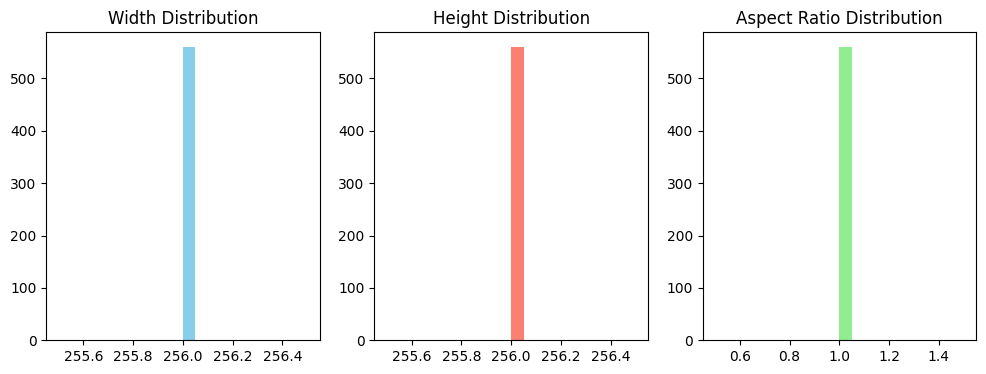

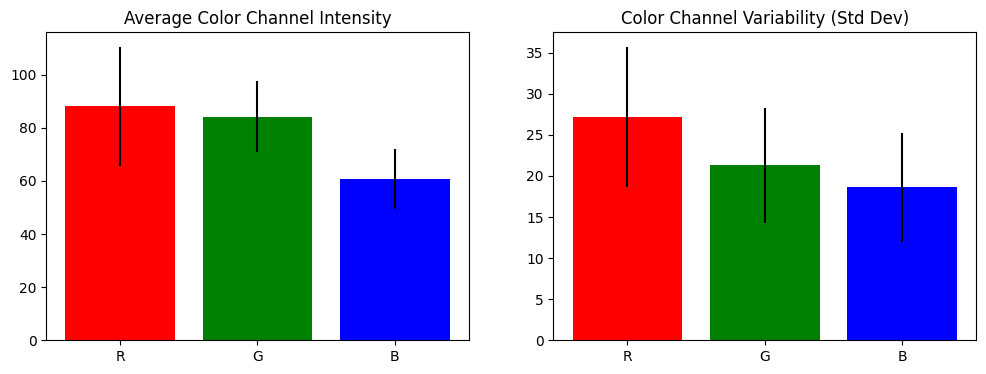

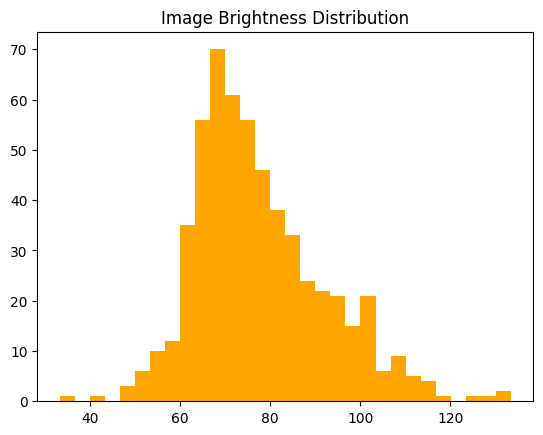

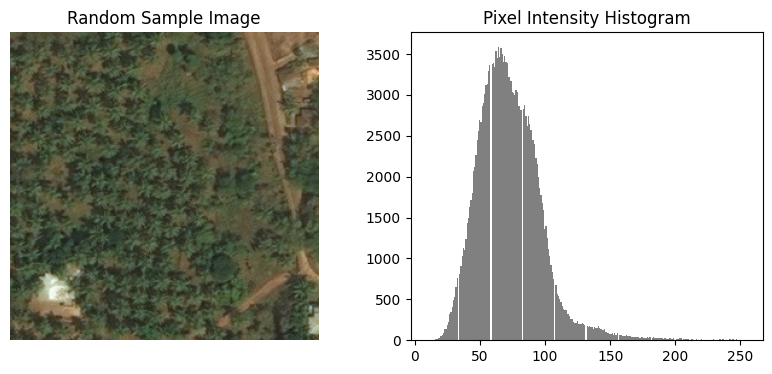

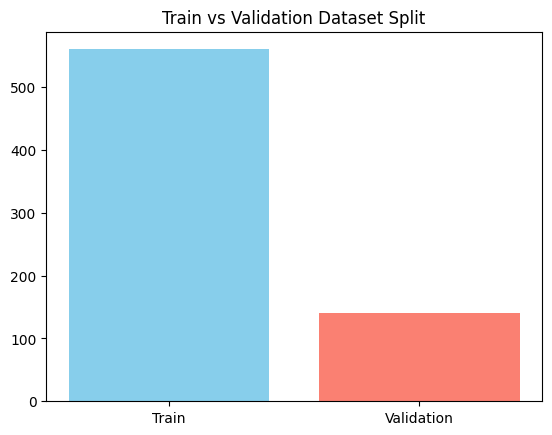

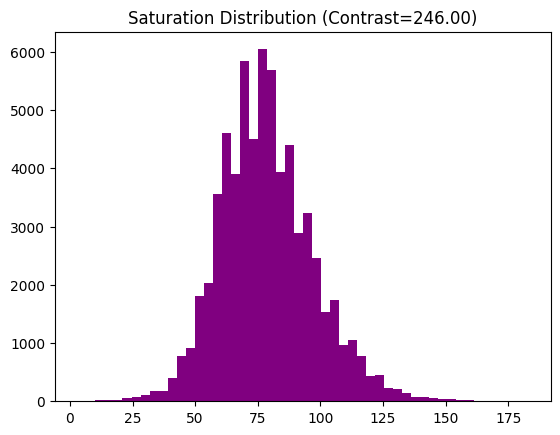

Image width range: 256 - 256 pixels
Image height range: 256 - 256 pixels
Aspect ratio range: 1.00 - 1.00
Brightness range: 33.31 - 133.41


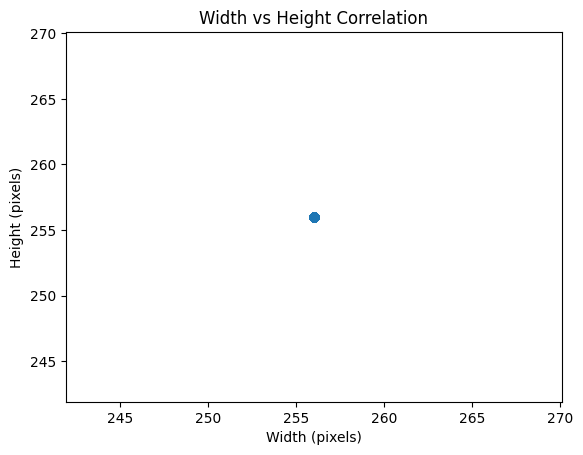

In [3]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# -------------------------
# Define paths to training and validation image folders
train_folder = "yolo_dataset_small/images/train"
val_folder = "yolo_dataset_small/images/val"

# -------------------------
# Count total images in train and validation sets
train_imgs = os.listdir(train_folder)
val_imgs = os.listdir(val_folder)

print(f"Total train images: {len(train_imgs)}")
print(f"Total validation images: {len(val_imgs)}")
print(f"Total images: {len(train_imgs)+len(val_imgs)}\n")

# -------------------------
# Analyze image dimensions and aspect ratios
# Collect width, height, and aspect ratio of each training image
widths, heights, aspect_ratios = [], [], []
for img_name in train_imgs:
    img = cv2.imread(os.path.join(train_folder, img_name))
    h, w = img.shape[:2]
    widths.append(w)
    heights.append(h)
    aspect_ratios.append(w/h)

# Plot distributions of width, height, and aspect ratio
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(widths, bins=20, color='skyblue')
plt.title("Width Distribution")
plt.subplot(1,3,2)
plt.hist(heights, bins=20, color='salmon')
plt.title("Height Distribution")
plt.subplot(1,3,3)
plt.hist(aspect_ratios, bins=20, color='lightgreen')
plt.title("Aspect Ratio Distribution")
plt.show()

# -------------------------
# Compute color channel statistics and brightness
# Calculate mean and standard deviation of RGB channels and overall brightness
means, stds, brightness = [], [], []
for img_name in train_imgs:
    img = cv2.imread(os.path.join(train_folder, img_name))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    means.append(img_rgb.mean(axis=(0,1)))
    stds.append(img_rgb.std(axis=(0,1)))
    brightness.append(img_rgb.mean())

means = np.array(means)
stds = np.array(stds)

# Visualize mean and standard deviation for RGB channels
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.bar(['R','G','B'], means.mean(axis=0), yerr=means.std(axis=0), color=['r','g','b'])
plt.title("Average Color Channel Intensity")
plt.subplot(1,2,2)
plt.bar(['R','G','B'], stds.mean(axis=0), yerr=stds.std(axis=0), color=['r','g','b'])
plt.title("Color Channel Variability (Std Dev)")
plt.show()

# Brightness distribution histogram
plt.hist(brightness, bins=30, color='orange')
plt.title("Image Brightness Distribution")
plt.show()

# -------------------------
# Visualize a random sample image and its pixel intensity histogram
sample_img_name = random.choice(train_imgs)
img = cv2.imread(os.path.join(train_folder, sample_img_name))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Random Sample Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.hist(img_rgb.ravel(), bins=256, color='gray')
plt.title("Pixel Intensity Histogram")
plt.show()

# -------------------------
# Compare number of images in train vs validation sets
plt.bar(['Train','Validation'], [len(train_imgs), len(val_imgs)], color=['skyblue','salmon'])
plt.title("Train vs Validation Dataset Split")
plt.show()

# -------------------------
# Analyze saturation and contrast of the sample image
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
saturation = img_hsv[:,:,1].ravel()
contrast = img_rgb.max() - img_rgb.min()

plt.hist(saturation, bins=50, color='purple')
plt.title(f"Saturation Distribution (Contrast={contrast:.2f})")
plt.show()

# -------------------------
# Detect potential outliers in dimensions and brightness
print(f"Image width range: {min(widths)} - {max(widths)} pixels")
print(f"Image height range: {min(heights)} - {max(heights)} pixels")
print(f"Aspect ratio range: {min(aspect_ratios):.2f} - {max(aspect_ratios):.2f}")
print(f"Brightness range: {min(brightness):.2f} - {max(brightness):.2f}")

# -------------------------
# Optional: Mask coverage ratio (skipped since masks are not used)
# Example placeholder: coverage = np.sum(mask>0)/mask.size

# -------------------------
# Explore correlation between width and height of images
plt.scatter(widths, heights, alpha=0.5)
plt.title("Width vs Height Correlation")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.show()


In [4]:
!conda install -c conda-forge ultralytics -y


'conda' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
# ---------------------------
# YOLOv8 Forest Segmentation Training in Notebook
# ---------------------------
from ultralytics import YOLO

# Load the YOLOv8 segmentation model
model = YOLO("yolov8n-seg.pt")  # base pretrained segmentation model

# Train the model
model.train(
    task="segment",            # segmentation task
    data="dataset_small.yaml", # your dataset YAML
    epochs=40,                 # number of epochs
    batch=8,                   # batch size
    imgsz=640,                 # image size
    pretrained=True,           # use pretrained weights
    save=True,                 # save best.pt automatically
    patience=50,               # early stopping patience
    val=True,                  # run validation
    overlap_mask=True,         # segmentation mask augmentation
    mask_ratio=4,              # mask augmentation ratio
    amp=True                   # automatic mixed precision
)


New https://pypi.org/project/ultralytics/8.3.203 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.185  Python-3.11.4 torch-2.8.0+cpu CPU (12th Gen Intel Core(TM) i7-1255U)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_small.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train13, nbs=64, nms=False, opset=None, optimize=Fals

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

 21                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
 22        [15, 18, 21]  1   1004275  ultralytics.nn.modules.head.Segment          [1, 32, 64, [64, 128, 256]]   
YOLOv8n-seg summary: 151 layers, 3,263,811 parameters, 3,263,795 gradients, 11.5 GFLOPs

Transferred 381/417 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
train: Fast image access  (ping: 0.20.1 ms, read: 1.90.2 MB/s, size: 30.6 KB)


train: Scanning C:\Project\full ok\yolo_dataset_small\labels\train... 560 images, 0 backgrounds, 0 corrupt: 100%|██████████| 560/560 [00:02<00:00, 266.23it/s]


train: New cache created: C:\Project\full ok\yolo_dataset_small\labels\train.cache


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):  22%|██▏       | 2/9 [00:06<00:21,  3.08s/it]

WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validati

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:48<00:00,  5.44s/it]


                   all        140        173      0.737      0.555      0.619      0.464      0.676      0.509      0.538      0.353
Speed: 3.1ms preprocess, 286.8ms inference, 0.0ms loss, 31.2ms postprocess per image
Results saved to runs\segment\train13


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000277BAD1C590>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410


image 1/1 C:\Project\full ok\yolo_dataset_small\images\val\217085_sat_04.jpg: 640x640 1 forest, 230.7ms
Speed: 7.6ms preprocess, 230.7ms inference, 13.7ms postprocess per image at shape (1, 3, 640, 640)


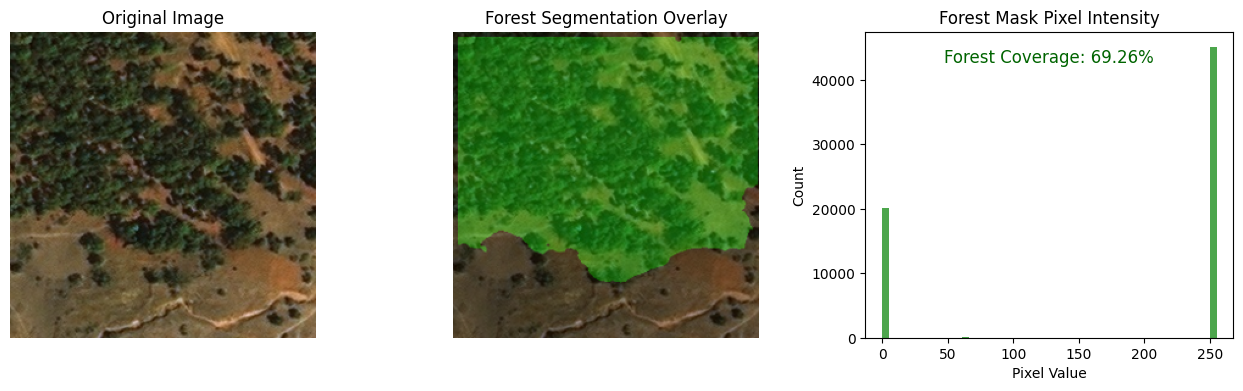

In [1]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# ---------------------------
# Load YOLO Model
# ---------------------------
MODEL_PATH = "runs/segment/train59/weights/best.pt"
model = YOLO(MODEL_PATH)

# ---------------------------
# Functions
# ---------------------------
class ForestSegmentationApp:
    def __init__(self, root):
        self.root = root
        self.root.title("🌲 Forest Segmentation GUI")
        
        # Screen dimensions
        self.screen_width = root.winfo_screenwidth()
        self.screen_height = root.winfo_screenheight()
        
        # Set window size to 80% of screen
        win_width = int(self.screen_width * 0.8)
        win_height = int(self.screen_height * 0.8)
        root.geometry(f"{win_width}x{win_height}+{int(self.screen_width*0.1)}+{int(self.screen_height*0.1)}")
        root.configure(bg="white")
        
        self.create_widgets()
    
    def create_widgets(self):
        # Top labels
        tk.Label(self.root, text="📥 Original Image", font=("Arial", 12, "bold"), bg="white").grid(row=0, column=0)
        tk.Label(self.root, text="🌳 Segmentation Result", font=("Arial", 12, "bold"), bg="white").grid(row=0, column=1)
        
        # Image panels
        self.original_label = tk.Label(self.root)
        self.original_label.grid(row=1, column=0, padx=10, pady=10, sticky="nsew")
        
        self.result_label = tk.Label(self.root)
        self.result_label.grid(row=1, column=1, padx=10, pady=10, sticky="nsew")
        
        # Make grid expandable
        self.root.grid_rowconfigure(1, weight=1)
        self.root.grid_columnconfigure(0, weight=1)
        self.root.grid_columnconfigure(1, weight=1)
        
        # Upload button
        upload_btn = tk.Button(self.root, text="📁 Upload & Visualize", command=self.upload_image,
                               bg="#2d89ef", fg="white", font=("Arial", 12))
        upload_btn.grid(row=2, column=0, columnspan=2, pady=10)
        
        # Detailed visualization frame
        self.detail_frame = tk.Frame(self.root, bg="white")
        self.detail_frame.grid(row=3, column=0, columnspan=2, pady=20, sticky="nsew")
        self.root.grid_rowconfigure(3, weight=1)
        
    def upload_image(self):
        for widget in self.detail_frame.winfo_children():
            widget.destroy()
        
        file_path = filedialog.askopenfilename(filetypes=[("Image files", "*.jpg *.png *.jpeg")])
        if file_path:
            orig_img, overlay_img, mask_resized = self.process_image(file_path)
            
            # Resize images to fit half the window
            max_w = int(self.screen_width * 0.35)
            max_h = int(self.screen_height * 0.35)
            orig_img.thumbnail((max_w, max_h))
            overlay_img.thumbnail((max_w, max_h))
            
            orig_tk = ImageTk.PhotoImage(orig_img)
            overlay_tk = ImageTk.PhotoImage(overlay_img)
            
            self.original_label.config(image=orig_tk)
            self.original_label.image = orig_tk
            self.result_label.config(image=overlay_tk)
            self.result_label.image = overlay_tk
            
            # Visualization
            fig = self.visualize_details(orig_img, overlay_img, mask_resized)
            canvas = FigureCanvasTkAgg(fig, master=self.detail_frame)
            canvas.draw()
            canvas.get_tk_widget().pack(fill="both", expand=True)
    
    def process_image(self, path):
        orig = cv2.imread(path)
        orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        orig_pil = Image.fromarray(orig)
        
        results = model.predict(source=path, conf=0.05, save=False)
        res = results[0]
        
        mask_resized = np.zeros(orig.shape[:2], dtype=np.uint8)
        if hasattr(res, "masks") and res.masks is not None:
            masks_data = res.masks.data
            if masks_data is not None and len(masks_data) > 0:
                combined_mask = np.zeros(masks_data[0].shape, dtype=np.float32)
                for m in masks_data:
                    combined_mask += m.cpu().numpy()
                combined_mask = np.clip(combined_mask, 0, 1)
                mask_resized = cv2.resize((combined_mask * 255).astype(np.uint8), (orig.shape[1], orig.shape[0]))
        
        mask_color = np.zeros_like(orig)
        mask_color[:, :, 1] = mask_resized
        overlay = cv2.addWeighted(orig, 0.7, mask_color, 0.3, 0)
        overlay_pil = Image.fromarray(overlay)
        
        return orig_pil, overlay_pil, mask_resized
    
    def visualize_details(self, orig_img, overlay_img, mask_resized):
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        axs[0].imshow(orig_img)
        axs[0].set_title("Original Image")
        axs[0].axis('off')
        
        axs[1].imshow(overlay_img)
        axs[1].set_title("Forest Segmentation Overlay")
        axs[1].axis('off')
        
        axs[2].hist(mask_resized.flatten(), bins=50, color='green', alpha=0.7)
        axs[2].set_title("Forest Mask Pixel Intensity")
        axs[2].set_xlabel("Pixel Value")
        axs[2].set_ylabel("Count")
        
        forest_pixels = np.sum(mask_resized > 0)
        total_pixels = mask_resized.size
        forest_percent = (forest_pixels / total_pixels) * 100
        axs[2].text(0.5, 0.9, f"Forest Coverage: {forest_percent:.2f}%",
                    transform=axs[2].transAxes, fontsize=12, ha='center', color='darkgreen')
        
        plt.tight_layout()
        return fig

# ---------------------------
# Launch GUI
# ---------------------------
if __name__ == "__main__":
    root = tk.Tk()
    app = ForestSegmentationApp(root)
    root.mainloop()
